# Group Project - Group 5
# Names: Mitchell Nasser, Alexander Tobias, Sommojoty Dasgupta

In [2]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from transformers import AutoTokenizer, TFBertForSequenceClassification, TFRobertaForSequenceClassification
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [4]:
train_df = pd.read_csv(
    "yelp_review_polarity_csv/yelp_review_polarity_csv/train_small.csv",
    header=None,
    names=["label", "text"]
)

test_df = pd.read_csv(
    "yelp_review_polarity_csv/yelp_review_polarity_csv/test_small.csv",
    header=None,
    names=["label", "text"]
)

train_df["label"] = train_df["label"] - 1
test_df["label"] = test_df["label"] - 1

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["text"].tolist(),
    train_df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

test_texts = test_df["text"].tolist()
test_labels = test_df["label"].tolist()

print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))
print("Test size:", len(test_texts))

print("\nTrain label counts:")
print(train_df["label"].value_counts().sort_index())

Train size: 16000
Validation size: 4000
Test size: 2000

Train label counts:
label
0    10002
1     9998
Name: count, dtype: int64


# BERT Model Setup

1. `HF_BERT_NAME = "bert-base-uncased"` - Specifies which pre-trained BERT model to use from Hugging Face's model hub.

2. `MAX_LEN = 128` - Sets the maximum sequence length for text inputs.

3. `BATCH_SIZE = 32` - Defines how many samples will be processed together in each training batch.

4. `EPOCHS = 5` - Sets the number of complete passes through the training dataset.

5. `PATIENCE = 2` - Likely used for early stopping, indicating how many epochs to wait for improvement before stopping training.

6. `bert_tokenizer = AutoTokenizer.from_pretrained(HF_BERT_NAME)` - Loads the tokenizer corresponding to the specified BERT model.

7. The `tokenize_bert()` function is defined to convert text inputs into the format required by BERT models, including:
   - Padding sequences to the same length
   - Truncating sequences that exceed the maximum length
   - Returning the necessary tensors (input_ids, attention_mask, token_type_ids) for BERT processing

In [5]:
HF_BERT_NAME = "bert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 5
PATIENCE = 2

bert_tokenizer = AutoTokenizer.from_pretrained(HF_BERT_NAME)

def tokenize_bert(texts, max_len=MAX_LEN):
    enc = bert_tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=max_len,
        return_tensors="np"
    )

    return {
        "input_ids": enc["input_ids"].astype("int32"),
        "attention_mask": enc["attention_mask"].astype("int32"),
        "token_type_ids": enc["token_type_ids"].astype("int32"),
    }

train_labels = np.array(train_labels, dtype="int32")
val_labels = np.array(val_labels, dtype="int32")
test_labels = np.array(test_labels, dtype="int32")

C:\Users\sommo\anaconda3\envs\nlp_env\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /bert-base-uncased/resolve/main/tokenizer_config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: bbea5586-9409-4b64-9303-6dbc3373bbb6)')' thrown while requesting HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /bert-base-uncased/resolve/main/tokenizer_config.json (Caused by NameResolutionError("HTT

# BERT Model Training

1. First, it tokenizes the text data using a function called `tokenize_bert()` for training, validation, and test datasets.

2. It loads a pre-trained BERT model ("bert-base-uncased") using the `TFBertForSequenceClassification` class, configuring it for binary classification with `num_labels=2`.

3. The code freezes the BERT backbone layers with `bert_model.bert.trainable = False` to speed up training by only fine-tuning the classification head.

4. It displays the model architecture with `bert_model.summary()`.

5. The model is compiled with:
   - Adam optimizer with a small learning rate (5e-5)
   - Sparse categorical cross-entropy loss (appropriate for classification tasks)
   - Accuracy as the evaluation metric

6. Two callbacks are defined:
   - Early stopping to prevent overfitting
   - Model checkpoint to save the best model weights

7. The model is trained with `fit()`, using the training data and validating on validation data.

8. Finally, it evaluates the model on the test set and prints the test loss and accuracy.

In [6]:
x_train_bert = tokenize_bert(train_texts)
x_val_bert = tokenize_bert(val_texts)
x_test_bert = tokenize_bert(test_texts)

bert_model = TFBertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

# Freeze BERT backbone for faster training
bert_model.bert.trainable = False

bert_model.summary()

bert_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

model_check = ModelCheckpoint(
    filepath="bert_best.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

bert_history = bert_model.fit(
    x=x_train_bert,
    y=train_labels,
    validation_data=(x_val_bert, val_labels),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop, model_check]
)


print("Testing Accuracy:")
bert_test_loss, bert_test_acc = bert_model.evaluate(
    x_test_bert,
    test_labels,
    batch_size=BATCH_SIZE
)

print("BERT Test Loss:", bert_test_loss)
print("BERT Test Accuracy:", bert_test_acc)

'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /bert-base-uncased/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: e10d5d0b-2126-4a89-93c2-6741fe330012)')' thrown while requesting HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /bert-base-uncased/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: d7b56c80-b4ea-47a3-88cd-e72b2aae154b)')' thrown while requesting HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'(MaxRetryError('HTTPSCo

Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
 dropout_37 (Dropout)        multiple                  0         
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
Total params: 109,483,778
Trainable params: 1,538
Non-trainable params: 109,482,240
_________________________________________________________________
Epoch 1/5
500/500 [==============================] - ETA: 0s - loss: 0.6816 - accuracy: 0.5689
Epoch 1: val_loss improved from inf to 0.66106, saving model to bert_best.weights.h5
500/500 [==============================] - 829s 2s/step - loss: 0.6816 - accuracy: 0.5689 - val_l

# BERT Tokenizer Demonstration
This converts the text into a format that can be processed by a BERT model, including tokenization, padding, and conversion to numerical IDs.

1. `sample_text = test_texts[0][:150]` - Takes the first 150 characters from the first text in the `test_texts` collection.

2. `encoded_sample = bert_tokenizer(...)` - Uses a pre-initialized BERT tokenizer to encode the sample text with several parameters:
   - `padding="max_length"` - Pads all sequences to the specified maximum length
   - `truncation=True` - Truncates sequences that exceed the maximum length
   - `max_length=50` - Sets the maximum sequence length to 50 tokens
   - `return_tensors="np"` - Returns the encoded data as NumPy arrays



In [7]:
sample_text = test_texts[0][:150]

encoded_sample = bert_tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=50,
    return_tensors="np"
)

print("Original Text:")
print(sample_text)

print("\nToken IDs:")
print(encoded_sample["input_ids"][0])

print("\nTokens:")
print(bert_tokenizer.convert_ids_to_tokens(encoded_sample["input_ids"][0]))

print("\nToken -> ID")
for token, token_id in zip(
    bert_tokenizer.convert_ids_to_tokens(encoded_sample["input_ids"][0]),
    encoded_sample["input_ids"][0]
):
    print(f"{token:15} -> {int(token_id)}")

Original Text:
mmmmm...,,,,mmm... bad! This place was definitely not what a majority of my co-workers had described it.  How can you burn chicken that bad? Here are 

Token IDs:
[  101 25391  7382  1012  1012  1012  1010  1010  1010  1010 25391  1012
  1012  1012  2919   999  2023  2173  2001  5791  2025  2054  1037  3484
  1997  2026  2522  1011  3667  2018  2649  2009  1012  2129  2064  2017
  6402  7975  2008  2919  1029  2182  2024   102     0     0     0     0
     0     0]

Tokens:
['[CLS]', 'mmm', '##mm', '.', '.', '.', ',', ',', ',', ',', 'mmm', '.', '.', '.', 'bad', '!', 'this', 'place', 'was', 'definitely', 'not', 'what', 'a', 'majority', 'of', 'my', 'co', '-', 'workers', 'had', 'described', 'it', '.', 'how', 'can', 'you', 'burn', 'chicken', 'that', 'bad', '?', 'here', 'are', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

Token -> ID
[CLS]           -> 101
mmm             -> 25391
##mm            -> 7382
.               -> 1012
.               -> 1012
.      

# BERT Model Interpretation
The code also defines a `label_map` dictionary that maps numeric labels (0, 1) to human-readable labels ("negative", "positive").

1. `predict_with_bert(model, text, max_len=64)` - This function:
   - Takes a trained BERT model, input text, and maximum sequence length
   - Tokenizes the input text using a BERT tokenizer
   - Prepares the model inputs (input_ids, attention_mask, token_type_ids)
   - Makes a prediction using the model
   - Converts logits to probabilities using softmax
   - Returns the predicted label (mapped from numeric to text using label_map) and confidence score

2. `show_random_predictions(model, texts, labels, n=3)` - This function:
   - Randomly selects n samples from the provided texts
   - For each sample, gets the prediction using predict_with_bert
   - Prints the review text, actual label, predicted label, and confidence score
   - Uses formatting to make the output readable

In [8]:
label_map = {
    0: "negative",
    1: "positive"
}

def predict_with_bert(model, text, max_len=64):
    encoded = bert_tokenizer(
        [text],
        padding="max_length",
        truncation=True,
        max_length=max_len,
        return_tensors="np"
    )

    model_inputs = {
        "input_ids": encoded["input_ids"].astype("int32"),
        "attention_mask": encoded["attention_mask"].astype("int32"),
        "token_type_ids": encoded["token_type_ids"].astype("int32"),
    }

    outputs = model.predict(model_inputs, verbose=0)
    logits = outputs.logits

    probs = tf.nn.softmax(logits, axis=-1).numpy()[0]
    pred = int(np.argmax(probs))
    conf = float(np.max(probs))

    return label_map[pred], conf


def show_random_predictions(model, texts, labels, n=3):
    indices = random.sample(range(len(texts)), n)

    for idx in indices:
        text = texts[idx]
        true_label = int(labels[idx])

        pred_label, confidence = predict_with_bert(model, text, max_len=MAX_LEN)

        print("\n" + "=" * 80)
        print("Review:")
        print(text[:500])
        print("\nActual Label:   ", label_map[true_label])
        print("Predicted Label:", pred_label)
        print("Confidence:     ", f"{confidence:.4f}")

show_random_predictions(bert_model, test_texts, test_labels, n=3)


Review:
Run to Alexander Michael's this Christmas season for dinner or drinks.  You will thank me.   \n\nTucked away in 4th Ward (which in and of itself is reason enough to head to A.M.) it is quaint and, right now, decorated with lovely garlands and greenery and twinkling lights (I love twinkly things).  It truly looks out of a movie.  And the houses around it are also decorated so sweetly.  A little bit magical.  \n\nI was a 4th Ward resident and kinda lived at A.M. for a few years and had not been in

Actual Label:    positive
Predicted Label: negative
Confidence:      0.6165

Review:
Sunday evening my hubby & I were looking for a place to have dinner & The Vig came to mind so off we went. It was pretty early, about 5:45pm, so we beat the dinner crowd. We were seated in a comfy booth with a view of their open area patio. I know this is such a girl thing to say, but I love their bathroom sinks! \n\nFor starters we got the crab & artichoke dip. It was rich & creamy & just the right a

# Results Interpretation:
1. The model is not very confident in its predictions which indicates uncertainty.
2. The model is only learning a classifier layer on top of the pretrained embeddings.

The BERT model demonstrates a reasonable performance, correctly identifying some positive reviews. However, it struggles with certain positive examples, occasionally predicting them as negative. The confidence scores are moderate, indicating that the model is somewhat uncertain in its predictions.

# BERT Model Evaluation
This evaluates how well the BERT model performs on sentiment classification.
1. `bert_outputs = bert_model.predict(x_test_bert, batch_size=BATCH_SIZE)` - Uses the trained BERT model to generate predictions on the test data, processing in batches of size BATCH_SIZE.

2. `bert_logits = bert_outputs.logits` - Extracts the logits (raw prediction scores before softmax) from the model outputs.

3. `bert_preds = np.argmax(bert_logits, axis=1)` - Converts the logits to class predictions by taking the index of the highest value along axis 1 (the class dimension).

4. The print statements display:
   - A classification report showing precision, recall, F1-score, and support for each class ("negative" and "positive")
   - A confusion matrix showing the counts of true positives, false positives, true negatives, and false negatives

In [9]:
bert_outputs = bert_model.predict(x_test_bert, batch_size=BATCH_SIZE)
bert_logits = bert_outputs.logits
bert_preds = np.argmax(bert_logits, axis=1)

print("\nBERT Classification Report:")
print(classification_report(test_labels, bert_preds, target_names=["negative", "positive"]))
print("\nBERT Confusion Matrix:")
print(confusion_matrix(test_labels, bert_preds))

63/63 [==============================] - 93s 1s/step

BERT Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.79      0.76       996
    positive       0.77      0.71      0.74      1004

    accuracy                           0.75      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.75      0.75      0.75      2000


BERT Confusion Matrix:
[[785 211]
 [287 717]]


# Results Interpretation: 
The BERT model achieved 75% accuracy with balanced performance across both positive and negative reviews. It performs slightly better at identifying negative reviews. However, it tends to misclassify some positive reviews as negative, resulting in a higher number of false negatives. Overall, the model demonstrates stable and consistent performance, but could benefit from further fine-tuning to improve detection for positive reviews.

# RoBERTa Tokenizer Setup

1. `HF_ROBERTA_NAME = "roberta-base"` - Defines a variable with the name of the pre-trained RoBERTa model to use.

2. `MAX_LEN = 128` - Sets the maximum sequence length for tokenized inputs.

3. `BATCH_SIZE = 32` - Defines the batch size for model training.

4. `EPOCHS = 5` - Sets the number of training epochs.

5. `PATIENCE = 2` - Likely for early stopping patience.

6. `roberta_tokenizer = AutoTokenizer.from_pretrained(HF_ROBERTA_NAME)` - Loads the tokenizer for the RoBERTa model from Hugging Face.

7. The `tokenize_roberta` function:
   - Takes text inputs and a max length parameter
   - Uses the RoBERTa tokenizer to encode the texts with padding, truncation, and a maximum length
   - Returns a dictionary with the tokenized "input_ids" and "attention_mask" as NumPy arrays with int32 data type

In [13]:
HF_ROBERTA_NAME = "roberta-base"
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 5
PATIENCE = 2

roberta_tokenizer = AutoTokenizer.from_pretrained(HF_ROBERTA_NAME)

def tokenize_roberta(texts, max_len=MAX_LEN):
    encoded = roberta_tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=max_len,
        return_tensors="np"
    )

    return {
        "input_ids": encoded["input_ids"].astype("int32"),
        "attention_mask": encoded["attention_mask"].astype("int32"),
    }

# RoBERTa Model Setup and Training

1. First, it tokenizes the text data using a function called `tokenize_roberta()` for training, validation, and test datasets.

2. It loads a pre-trained RoBERTa model for sequence classification with 2 output classes using the `from_pretrained()` method.

3. The code then freezes the RoBERTa backbone layers by setting `roberta_model.roberta.trainable = False`, which prevents these layers from being updated during training to speed up the process.

4. It displays a summary of the model architecture with `roberta_model.summary()`.

5. The model is compiled with:
   - Adam optimizer with a learning rate of 5e-5
   - Sparse categorical cross-entropy loss function (with from_logits=True)
   - Accuracy as the evaluation metric

6. Two callbacks are defined:
   - Early stopping to prevent overfitting
   - ModelCheckpoint to save the best model weights

7. The model is trained using the `fit()` method with the specified training data, validation data, batch size, epochs, and callbacks.

8. Finally, it evaluates the model on the test dataset and prints the test loss and accuracy.

In [14]:
x_train_roberta = tokenize_roberta(train_texts)
x_val_roberta = tokenize_roberta(val_texts)
x_test_roberta = tokenize_roberta(test_texts)

roberta_model = TFRobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

# Freeze RoBERTa backbone for faster training
roberta_model.roberta.trainable = False

roberta_model.summary()

roberta_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

roberta_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

roberta_model_check = ModelCheckpoint(
    filepath="roberta_best.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

roberta_history = roberta_model.fit(
    x=x_train_roberta,
    y=train_labels,
    validation_data=(x_val_roberta, val_labels),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[roberta_early_stop, roberta_model_check]
)

print("Testing Accuracy:")
roberta_test_loss, roberta_test_acc = roberta_model.evaluate(
    x_test_roberta,
    test_labels,
    batch_size=BATCH_SIZE
)

print("RoBERTa Test Loss:", roberta_test_loss)
print("RoBERTa Test Accuracy:", roberta_test_acc)

C:\Users\sommo\anaconda3\envs\nlp_env\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sommo\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
All model checkpoint layers were used when initializing TFRobertaForSequenceClassification.

Some layers of TFRobertaFo

Model: "tf_roberta_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 roberta (TFRobertaMainLayer  multiple                 124055040 
 )                                                               
                                                                 
 classifier (TFRobertaClassi  multiple                 592130    
 ficationHead)                                                   
                                                                 
Total params: 124,647,170
Trainable params: 592,130
Non-trainable params: 124,055,040
_________________________________________________________________
Epoch 1/5
500/500 [==============================] - ETA: 0s - loss: 0.6471 - accuracy: 0.7002
Epoch 1: val_loss improved from inf to 0.59491, saving model to roberta_best.weights.h5
500/500 [==============================] - 1054s 2s/step - loss: 0.6471 - accuracy: 0.700

# RoBERTa Tokenizer Demonstration
This highlights how the RoBERTa model processes and represents text before feeding it into the neural network.

1. `sample_text = test_texts[0][:150]` - Takes the first 150 characters from the first text in the test dataset.

2. `encoded_sample = roberta_tokenizer(...)` - Tokenizes the sample text using the RoBERTa tokenizer with these parameters:
   - `padding="max_length"` - Pads the sequence to a fixed length
   - `truncation=True` - Truncates sequences longer than max_length
   - `max_length=50` - Sets the maximum sequence length to 50 tokens
   - `return_tensors="np"` - Returns NumPy arrays instead of lists

3. The code then prints:
   - The original text
   - The token IDs (numerical representations)
   - The actual tokens (text representations)
   - A mapping between each token and its corresponding ID

In [16]:
sample_text = test_texts[0][:150]

encoded_sample = roberta_tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=50,
    return_tensors="np"
)

print("Original Text:")
print(sample_text)

print("\nToken IDs:")
print(encoded_sample["input_ids"][0])

print("\nTokens:")
print(roberta_tokenizer.convert_ids_to_tokens(encoded_sample["input_ids"][0]))

print("\nToken -> ID")
for token, token_id in zip(
    roberta_tokenizer.convert_ids_to_tokens(encoded_sample["input_ids"][0]),
    encoded_sample["input_ids"][0]
):
    print(f"{token:15} -> {int(token_id)}")

Original Text:
mmmmm...,,,,mmm... bad! This place was definitely not what a majority of my co-workers had described it.  How can you burn chicken that bad? Here are 

Token IDs:
[    0  5471 41311   734 49563 41311   734  1099   328   152   317    21
  2299    45    99    10  1647     9   127  1029    12 16941    56  1602
    24     4  1437  1336    64    47  7403  5884    14  1099   116  1398
    32  1437     2     1     1     1     1     1     1     1     1     1
     1     1]

Tokens:
['<s>', 'mm', 'mmm', '...', ',,,,', 'mmm', '...', 'Ġbad', '!', 'ĠThis', 'Ġplace', 'Ġwas', 'Ġdefinitely', 'Ġnot', 'Ġwhat', 'Ġa', 'Ġmajority', 'Ġof', 'Ġmy', 'Ġco', '-', 'workers', 'Ġhad', 'Ġdescribed', 'Ġit', '.', 'Ġ', 'ĠHow', 'Ġcan', 'Ġyou', 'Ġburn', 'Ġchicken', 'Ġthat', 'Ġbad', '?', 'ĠHere', 'Ġare', 'Ġ', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

Token -> ID
<s>             -> 0
mm              -> 5471
mmm             -> 41311
...        

# RoBERTa Model Interpretation 
The demonstrates a practical way to evaluate and visualize model predictions on random samples.

1. `predict_with_roberta(model, text, max_len=MAX_LEN)`:
   - Takes a RoBERTa model, input text, and optional maximum length parameter
   - Tokenizes the input text using the RoBERTa tokenizer with padding and truncation
   - Prepares the model inputs with the correct data types
   - Makes a prediction using the model
   - Processes the output logits using softmax to get probabilities
   - Returns the predicted label and confidence score

2. `show_random_roberta_predictions(model, texts, labels, n=3)`:
   - Takes a model, lists of texts and labels, and number of samples to show
   - Randomly selects n indices from the dataset
   - For each selected sample:
     - Gets the prediction using the first function
     - Prints the review text (truncated to 500 characters)
     - Prints the actual label, predicted label, and confidence score
     - Formats the output with separators for readability

In [17]:
def predict_with_roberta(model, text, max_len=MAX_LEN):
    encoded = roberta_tokenizer(
        [text],
        padding="max_length",
        truncation=True,
        max_length=max_len,
        return_tensors="np"
    )

    model_inputs = {
        "input_ids": encoded["input_ids"].astype("int32"),
        "attention_mask": encoded["attention_mask"].astype("int32"),
    }

    outputs = model.predict(model_inputs, verbose=0)
    logits = outputs.logits

    probs = tf.nn.softmax(logits, axis=-1).numpy()[0]
    pred = int(np.argmax(probs))
    conf = float(np.max(probs))

    return label_map[pred], conf


def show_random_roberta_predictions(model, texts, labels, n=3):
    indices = random.sample(range(len(texts)), n)

    for idx in indices:
        text = texts[idx]
        true_label = int(labels[idx])

        pred_label, confidence = predict_with_roberta(model, text)

        print("\n" + "=" * 80)
        print("Review:")
        print(text[:500])
        print("\nActual Label:   ", label_map[true_label])
        print("Predicted Label:", pred_label)
        print("Confidence:     ", f"{confidence:.4f}")


show_random_roberta_predictions(roberta_model, test_texts, test_labels, n=3)


Review:
This is one of my go-to Starbucks.  Right off of Flamingo in the same parking lot as the LVAC.  Very good staff, and never as packed and busy as most of the other Starbucks in the area.  \n\nAlso has a drive-thru for those lazy mornings when that good song is on the radio and you don't feel like parking and going inside.

Actual Label:    positive
Predicted Label: positive
Confidence:      0.8574

Review:
My fianc\u00e9 and I stopped in for a quick dinner on a Tuesday night... The place was pretty empty. We sat at the bar, since it was the only place you get happy hour, service was attentive and quick. Since the appetizers were discounted for HH, we got 2. The corn and the \"pico de avocado\" were both fine, but pretty small portions. The menu is pretty simple and the decor is nice. We were both really disappointed in our food.... First I was sent out the wrong item. I ordered the chile rojo chic

Actual Label:    negative
Predicted Label: negative
Confidence:      0.7102

Rev

# Results Interpretation: 
1. RoBERTa is mostly confident when it comes to making correct predictions, especially for clearly expressed sentiment.
2. RoBERTa captures sentiment better in clear cases but still faces difficulty when reviews contain mixed signals or sarcasm.

RoBERTa shows improved confidence and strong performance on clearly positive and negative reviews. However, like BERT, it still makes errors on more complex or nuanced text, particularly when multiple sentiments are expressed within the same review.

# RoBERTa Model Evaluation
This is evaluating how well the RoBERTa model performed on a binary sentiment classification task (negative/positive).

1. `roberta_outputs = roberta_model.predict(x_test_roberta, batch_size=BATCH_SIZE)` - This line uses the RoBERTa model to make predictions on the test data, processing it in batches of size BATCH_SIZE.

2. `roberta_logits = roberta_outputs.logits` - This extracts the logits (raw prediction scores before softmax) from the model outputs.

3. `roberta_preds = np.argmax(roberta_logits, axis=1)` - This converts the logits to class predictions by taking the index of the highest score for each sample.

4. The `print` statements and function calls display evaluation metrics:
   - A classification report showing precision, recall, F1-score, and support for each class
   - A confusion matrix showing the counts of true positives, false positives, true negatives, and false negatives

In [18]:
roberta_outputs = roberta_model.predict(x_test_roberta, batch_size=BATCH_SIZE)
roberta_logits = roberta_outputs.logits
roberta_preds = np.argmax(roberta_logits, axis=1)

print("\nRoBERTa Classification Report:")
print(classification_report(test_labels, roberta_preds, target_names=["negative", "positive"]))

print("\nRoBERTa Confusion Matrix:")
print(confusion_matrix(test_labels, roberta_preds))

63/63 [==============================] - 109s 2s/step

RoBERTa Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.90      0.89       996
    positive       0.90      0.88      0.89      1004

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000


RoBERTa Confusion Matrix:
[[900  96]
 [124 880]]


# Resutls Interpretation: 
The RoBERTa model achieved 89% accuracy with highly balanced precision, recall, and F1-scores across both classes. It performs strongly in identifying both positive and negative reviews, with fewer misclassifications. The confusion matrix shows that errors are minimal and evenly distributed, indicating robust and reliable performance.

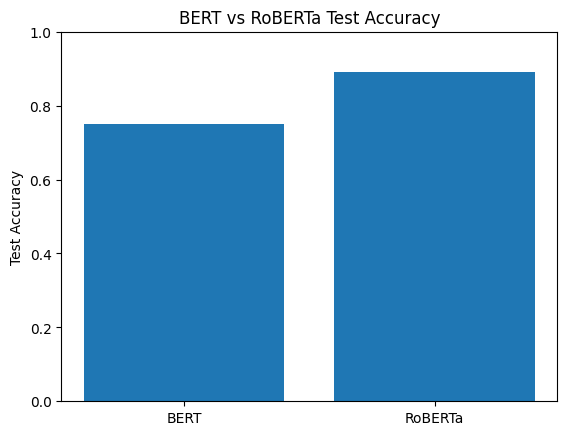

In [22]:
models = ["BERT", "RoBERTa"]
accuracies = [bert_test_acc, roberta_test_acc]

plt.bar(models, accuracies)
plt.ylabel("Test Accuracy")
plt.title("BERT vs RoBERTa Test Accuracy")
plt.ylim(0, 1)
plt.show()

# Explanation: 
The results show visually that RoBERTa outperforms BERT in test accuracy, indicating better overall performance in sentiment classification. This suggests that RoBERTa is more effective at understanding contextual relationships in text.

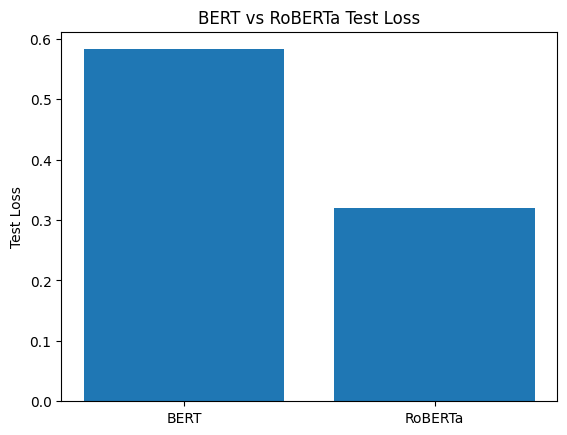

In [23]:
losses = [bert_test_loss, roberta_test_loss]

plt.bar(models, losses)
plt.ylabel("Test Loss")
plt.title("BERT vs RoBERTa Test Loss")
plt.show()

# Explanation:
The results show visually that RoBERTa achieves a much lower loss in the test dataset compared to BERT, indicating that its predictions are more precise and better aligned with the true labels.

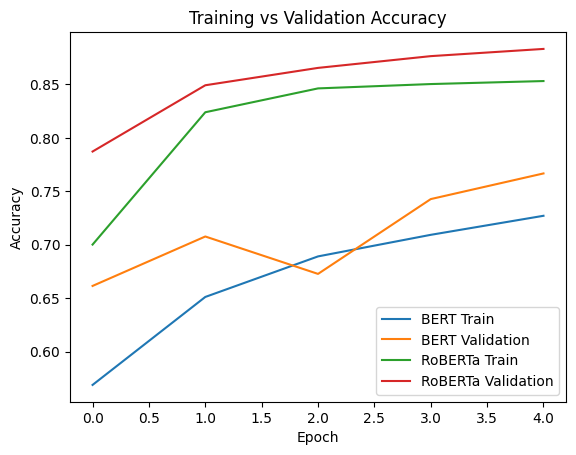

In [24]:
plt.plot(bert_history.history["accuracy"], label="BERT Train")
plt.plot(bert_history.history["val_accuracy"], label="BERT Validation")
plt.plot(roberta_history.history["accuracy"], label="RoBERTa Train")
plt.plot(roberta_history.history["val_accuracy"], label="RoBERTa Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Explanation: 
The plot shows that RoBERTa consistently achieves higher training and validation accuracy compared to BERT. It also converges faster and exhibits more stable learning behavior. While both models improve over time, RoBERTa demonstrates superior performance and generalization the more we train the models.

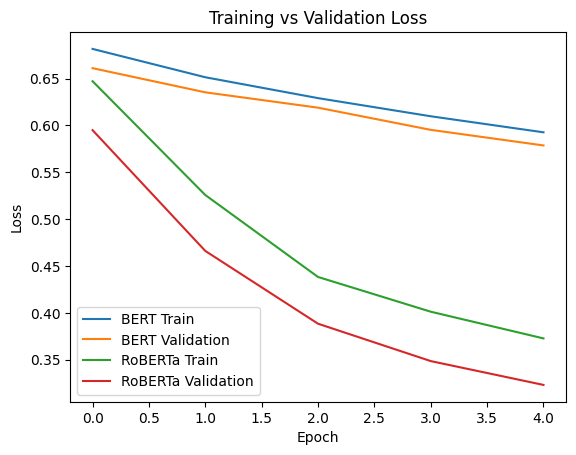

In [25]:
plt.plot(bert_history.history["loss"], label="BERT Train")
plt.plot(bert_history.history["val_loss"], label="BERT Validation")
plt.plot(roberta_history.history["loss"], label="RoBERTa Train")
plt.plot(roberta_history.history["val_loss"], label="RoBERTa Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Explanation:
The plot shows that both models improve over time, but RoBERTa achieves significantly lower loss compared to BERT. This indicates that RoBERTa produces more accurate and confident predictions. Additionally, the close alignment between training and validation loss suggests good generalization without overfitting the more we train the models.

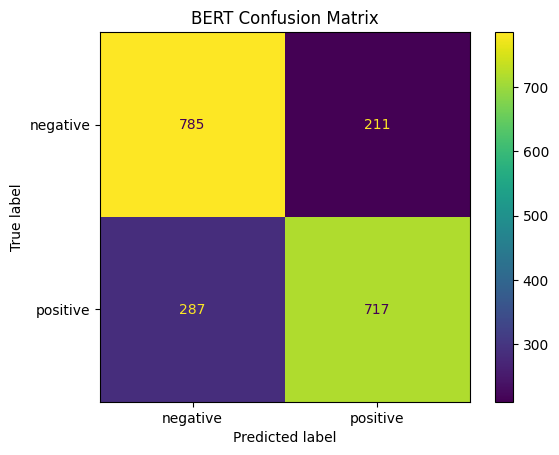

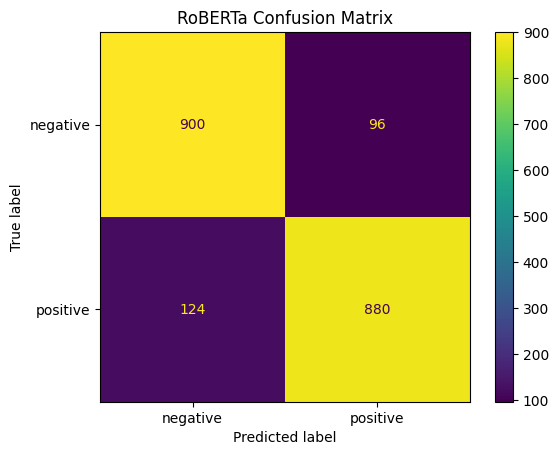

In [26]:
ConfusionMatrixDisplay.from_predictions(
    test_labels,
    bert_preds,
    display_labels=["negative", "positive"]
)
plt.title("BERT Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    roberta_preds,
    display_labels=["negative", "positive"]
)
plt.title("RoBERTa Confusion Matrix")
plt.show()

# Explanation: 
The confusion matrices shows that RoBERTa significantly outperforms BERT by increasing correct predictions and reducing classification errors. While BERT struggles particularly with positive reviews, RoBERTa demonstrates more balanced and accurate performance across both positive and negative reviews. BERT model has made 498 errors when classifying the reviews, while RoBERTa reduced these errors to 220. This highlights over a 50% reduction when misclassifying the labels. RoBERTa has false negative reviews at 124 which BERT has false negative reviews at 287, meaning it is much better at correctly identifying positive reviews.